<a href="https://colab.research.google.com/github/Abimaleh/data-science-portfolio/blob/criativos/amazon_books_analyze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                                Name  \
0                      10-Day Green Smoothie Cleanse   
1                                  11/22/63: A Novel   
2            12 Rules for Life: An Antidote to Chaos   
3                             1984 (Signet Classics)   
4  5,000 Awesome Facts (About Everything!) (Natio...   

                     Author  User Rating  Reviews  Price  Year        Genre  
0                  JJ Smith          4.7    17350      8  2016  Non Fiction  
1              Stephen King          4.6     2052     22  2011      Fiction  
2        Jordan B. Peterson          4.7    18979     15  2018  Non Fiction  
3             George Orwell          4.7    21424      6  2017      Fiction  
4  National Geographic Kids          4.8     7665     12  2019  Non Fiction  
(550, 7)
Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')
       User Rating       Reviews       Price         Year
count   550.000000    550.000000  

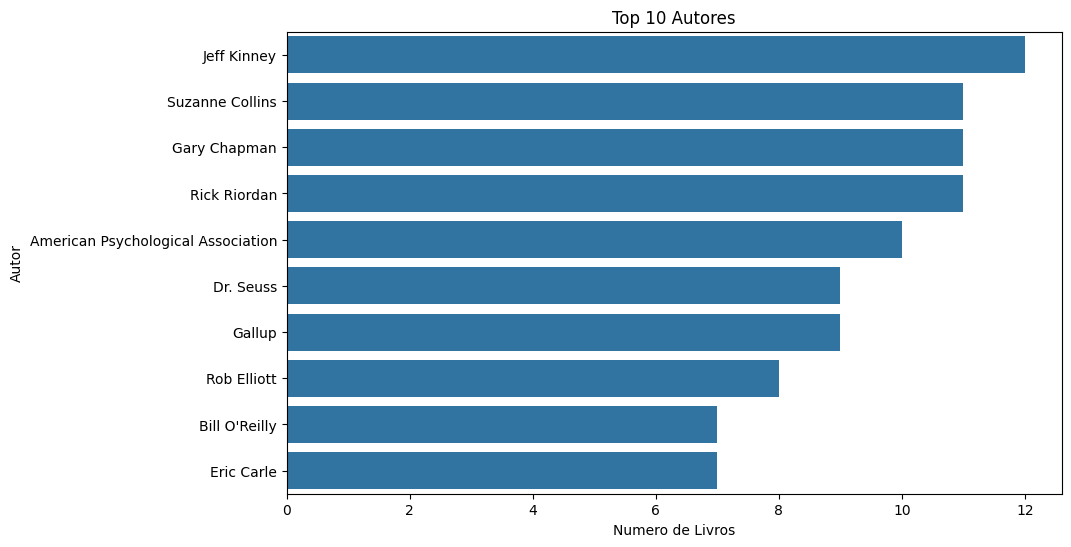

In [6]:
#importando as bibliotecas necessarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#abrir o arquivo csv
df = pd.read_csv("/content/drive/MyDrive/data-science-projects/amazon books analyze/bestsellers.csv")

#exploraçao inicial dos dados
print(df.head())
print(df.shape)
print(df.columns)
print(df.describe())

#limpar e organizar os dados
df.drop_duplicates(inplace=True)
df.rename(columns={'Name': "Nome", 'Author': "Autor", 'User Rating': "Avaliacao", 'Reviews': "Comentarios", 'Price': "Preço", 'Year': "Ano", 'Genre': "Genero"}, inplace=True)
print(df.columns)
df["Preço"] = df["Preço"].astype(float)

#Iniciar a analise
#1. Analisar popularidade dos autores

autor_counts = df["Autor"].value_counts()
print(autor_counts)

#2. Media de avaliações por genero
media_por_genero = df.groupby("Genero")["Avaliacao"].mean()
print(media_por_genero)

#exportar resultados da analise inicial
autor_counts.head(10).to_csv("/content/drive/MyDrive/data-science-projects/amazon books analyze/Top_autores.csv")
media_por_genero.to_csv("/content/drive/MyDrive/data-science-projects/amazon books analyze/Avaliacao_media_por_genero.csv")

#Criar visualização dos dados em formato de graficos
#top 10 autores mais populares
top_autores = autor_counts.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_autores.values, y=top_autores.index)
plt.title("Top 10 Autores")
plt.xlabel("Numero de Livros")
plt.ylabel("Autor")
plt.show()